In [2]:
import pandas as pd
df1 = pd.read_excel("../data/raw-data/MEdata_07-03-26.xlsx")
df1.to_csv("../data/raw-data/MEdata_07-03-26.csv", index=False)

In [3]:
df = pd.read_csv("../data/raw-data/MEdata_07-03-26.csv" )
print(df.head())
print(df.info())

         WEEK       REGION  COUNTRY   ADMIN1                  EVENT_TYPE  \
0  2016-02-06  Middle East  Bahrain  Capital                     Battles   
1  2026-02-28  Middle East  Bahrain  Capital  Explosions/Remote violence   
2  2026-03-07  Middle East  Bahrain  Capital  Explosions/Remote violence   
3  2016-06-25  Middle East  Bahrain  Capital  Explosions/Remote violence   
4  2017-02-11  Middle East  Bahrain  Capital  Explosions/Remote violence   

                  SUB_EVENT_TYPE  EVENTS  FATALITIES  POPULATION_EXPOSURE  \
0                    Armed clash       1           0              69821.0   
1               Air/drone strike       9           0               9077.0   
2               Air/drone strike       7           1                  NaN   
3  Remote explosive/landmine/IED       1           1               5568.0   
4  Remote explosive/landmine/IED       2           0               4084.0   

        DISORDER_TYPE     ID  CENTROID_LATITUDE  CENTROID_LONGITUDE  
0  Politic

In [4]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144526 entries, 0 to 144525
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   WEEK                 144526 non-null  object 
 1   REGION               144526 non-null  object 
 2   COUNTRY              144526 non-null  object 
 3   ADMIN1               144526 non-null  object 
 4   EVENT_TYPE           144526 non-null  object 
 5   SUB_EVENT_TYPE       144526 non-null  object 
 6   EVENTS               144526 non-null  int64  
 7   FATALITIES           144526 non-null  int64  
 8   POPULATION_EXPOSURE  113673 non-null  float64
 9   DISORDER_TYPE        144526 non-null  object 
 10  ID                   144516 non-null  float64
 11  CENTROID_LATITUDE    144526 non-null  float64
 12  CENTROID_LONGITUDE   144526 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 14.3+ MB


WEEK                       0
REGION                     0
COUNTRY                    0
ADMIN1                     0
EVENT_TYPE                 0
SUB_EVENT_TYPE             0
EVENTS                     0
FATALITIES                 0
POPULATION_EXPOSURE    30853
DISORDER_TYPE              0
ID                        10
CENTROID_LATITUDE          0
CENTROID_LONGITUDE         0
dtype: int64

In [5]:
df['COUNTRY'].value_counts() #top countries

COUNTRY
Yemen                   30946
Syria                   28485
Turkey                  22653
Iraq                    22541
Iran                    13115
Palestine                7279
Lebanon                  7158
Israel                   5629
Bahrain                  2682
Jordan                   2143
Saudi Arabia             1553
Kuwait                    135
Oman                       76
Qatar                      68
United Arab Emirates       63
Name: count, dtype: int64

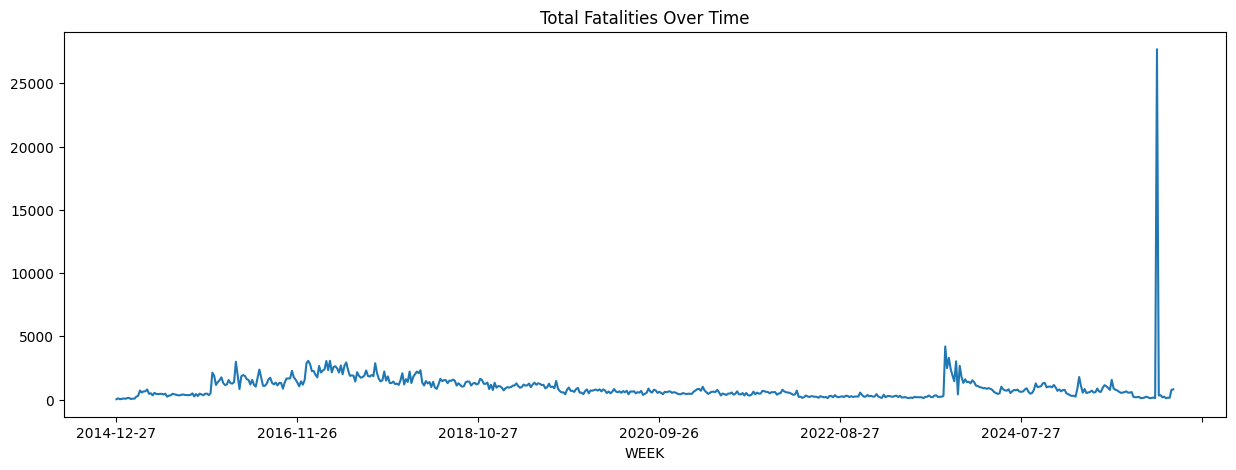

In [ ]:
import matplotlib.pyplot as plt

df.groupby('WEEK')['FATALITIES'].sum().plot(figsize=(15,5))
plt.title("Total Fatalities Over Time")
plt.show()
print(df.groupby('WEEK')['FATALITIES'].max)


In [17]:
print(df.groupby('WEEK')['FATALITIES'].sum().sort_values(ascending=False).head(10))

WEEK
2026-01-03    27696
2023-10-07     4200
2023-10-21     3297
2017-04-01     3069
2017-01-07     3060
2017-03-18     3050
2023-11-18     3022
2016-04-02     2989
2017-06-03     2937
2017-09-23     2869
Name: FATALITIES, dtype: int64


In [19]:
print(df.groupby('COUNTRY')['FATALITIES'].sum().sort_values(ascending=False).head(10))

COUNTRY
Yemen           166972
Syria           142994
Iraq            107616
Palestine        72186
Iran             32811
Turkey            9710
Saudi Arabia      6501
Lebanon           6224
Israel            2040
Jordan             204
Name: FATALITIES, dtype: int64


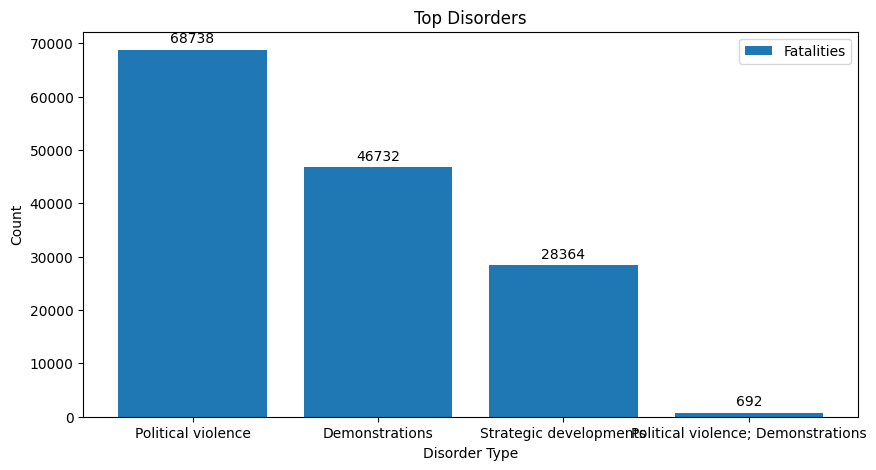

In [32]:
df.groupby('DISORDER_TYPE')['FATALITIES'].count().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
disorder_bar=plt.bar(df.groupby('DISORDER_TYPE')['FATALITIES'].count().sort_values(ascending=False).head(10).index, df.groupby('DISORDER_TYPE')['FATALITIES'].count().sort_values(ascending=False).head(10).values, label="Fatalities")
plt.title("Top Disorders")
plt.xlabel("Disorder Type")
plt.ylabel("Count")
plt.bar_label(disorder_bar, padding=3)
plt.legend()
plt.show()

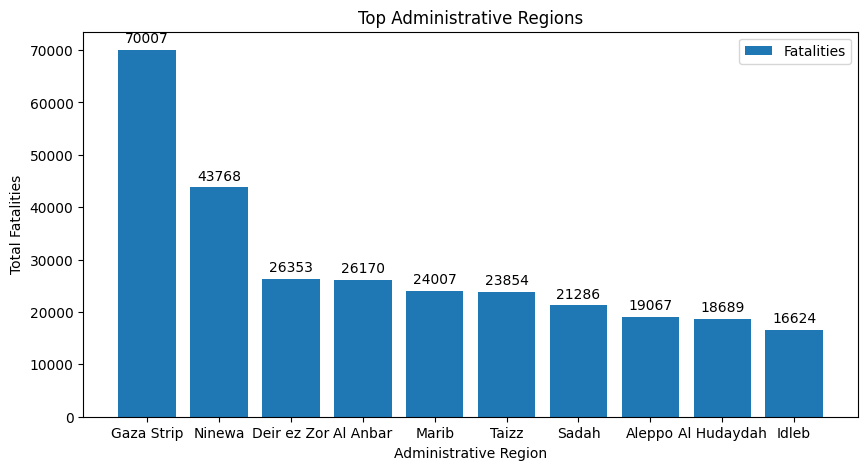

In [36]:
ADMIN_BAR = df.groupby('ADMIN1')['FATALITIES'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
admin_bar=plt.bar(ADMIN_BAR.index, ADMIN_BAR.values, label="Fatalities")
plt.title("Top Administrative Regions")
plt.xlabel("Administrative Region")
plt.ylabel("Total Fatalities")
plt.bar_label(admin_bar, padding=3)
plt.legend()
plt.show()


<Axes: xlabel='WEEK'>

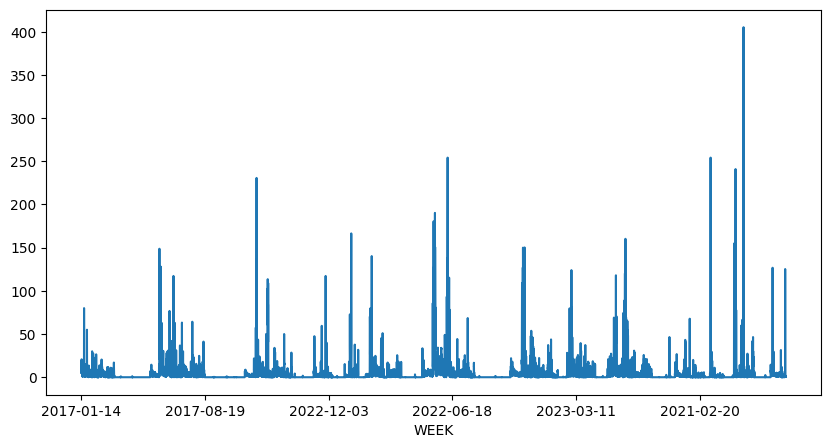

In [38]:
df_country = df[df['COUNTRY'] == 'Syria'].set_index('WEEK')

df_country['FATALITIES'].rolling(4).mean().plot(figsize=(10,5))

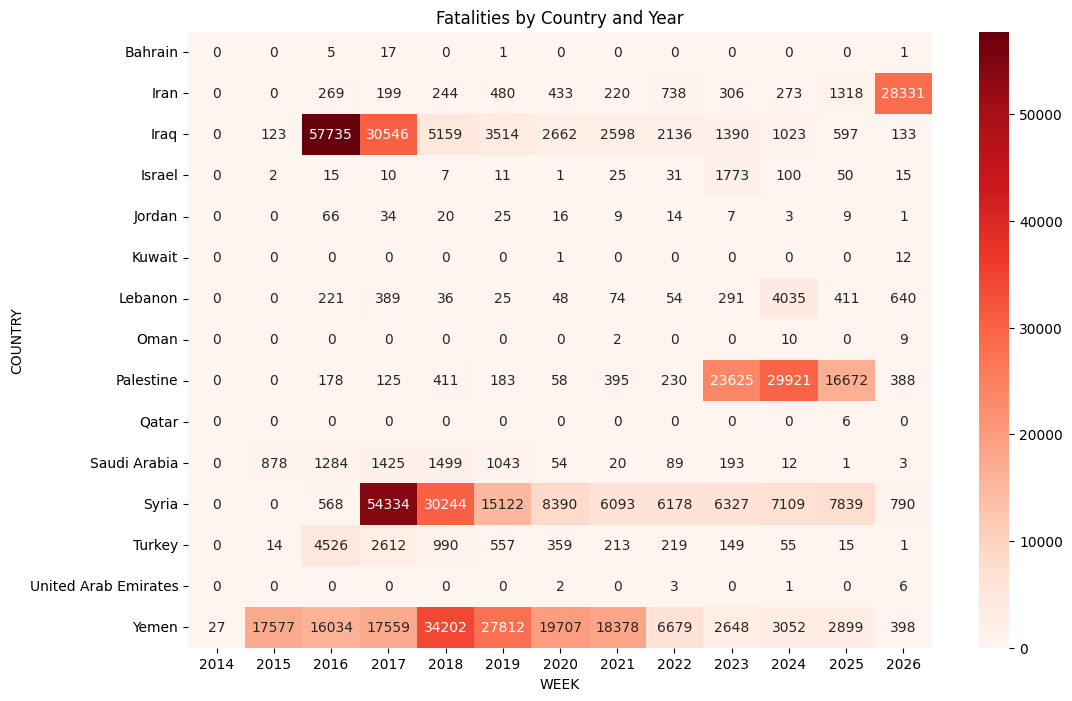

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'WEEK' is datetime
df['WEEK'] = pd.to_datetime(df['WEEK'])

# Create the pivot table with explicit aggregation and fill missing values
pivot_map = df.pivot_table(
    values='FATALITIES', 
    index='COUNTRY', 
    columns=df['WEEK'].dt.year, 
    aggfunc='sum',     # Use 'sum' for total or 'count' for frequency
    fill_value=0       # Fills NaN with 0 for a cleaner heatmap
)

# Plotting
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_map, cmap='Reds', annot=True, fmt='g') # 'annot' shows the numbers
plt.title("Fatalities by Country and Year")
plt.show()

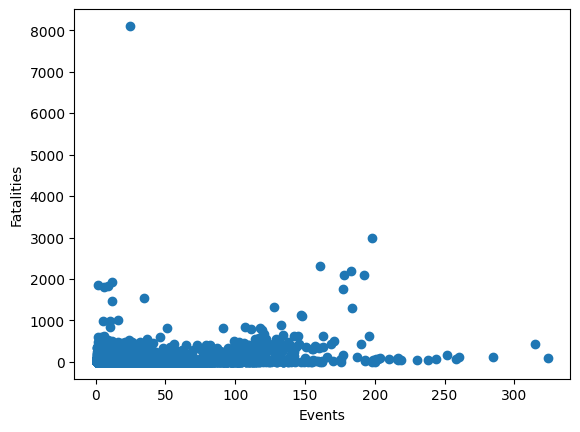

In [54]:


plt.scatter(df['EVENTS'], df['FATALITIES'])
plt.xlabel("Events")
plt.ylabel("Fatalities")
plt.show()